<a href="https://colab.research.google.com/github/vg137/ibd-causal-multiomics/blob/main/nb2_gene_set_expressions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction and setup

Gene sets are a collection of genes based on some common feature, usually a biological function. The goal of this notebook is to find the expression values of the hallmark gene sets in biological samples taken from actual patients of IBD

In [134]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns

In [136]:
data_dir = "/content/drive/My Drive/Colab Notebooks/Genomics project/ibd_data"

# Gene expression data from GEO

We first get a GEO dataset which will contain the expresssion values (in this case, RNA-Seq TPM values) for different genes in different biological samples from patients of IBD (specifically, Ulcerative Colitis and Crohn's disease)

In [137]:
expression_subdir = "expressions"
geo_series_name = "GSE57945"
expression_filepath = f"{data_dir}/{expression_subdir}/{geo_series_name}/{geo_series_name}_norm_counts_TPM_GRCh38.p13_NCBI.tsv.gz"

snp2gene_subdir = "snp2gene"
snp2gene_filepath = f"{data_dir}/{snp2gene_subdir}/GCST90292538_snp2gene.parquet"

We can load the expression matrix with the expression values of different samples

In [138]:
expr_df = pd.read_csv(
    expression_filepath,
    sep="\t",
    index_col=0,
)
expr_df.head()

,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598720,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729
GeneID,,,,,,,,,,,,,,,,,,,,,
100287102,0.1633,0.2159,0.06581,0.0955,0.000,0.2063,0.282,0.355,0.2475,0.000,...,0.07788,0.0943,0.000,0.248,0.2734,0.1704,0.2731,0.1742,0.1736,0.2991
653635,7.3950,4.3020,9.34200,7.6700,3.146,11.6600,20.540,15.080,13.6300,7.360,...,18.04000,28.0900,12.810,18.600,23.2300,21.7900,35.4000,20.9800,10.9400,24.6700
102466751,3.9660,3.4970,4.79700,2.3200,1.860,5.0120,15.980,8.625,2.0040,1.896,...,13.24000,13.7500,8.768,10.040,9.9620,8.2770,15.9300,10.5800,4.2170,12.1100
107985730,0.0000,0.0000,0.00000,0.0000,0.000,0.0000,0.000,0.000,0.0000,0.000,...,0.00000,0.0000,0.000,0.000,0.4197,0.0000,0.1677,0.0000,0.0000,0.0000
100302278,0.0000,0.0000,0.00000,0.0000,0.000,0.0000,0.000,0.000,0.0000,0.000,...,0.00000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Let us see how many rows and columns this dataframe has

In [139]:
expr_df.shape

(39376, 322)

So, we have 39376 different genes and 322 biological samples from which the RNA was sequenced

We will map the gene IDs to the gene symbols using the NCBI `gene_info` file for humans

In [140]:
geneID2symbol_subdir = "geneID2symbol"
geneID2symbol_filepath = f"{data_dir}/{geneID2symbol_subdir}/Homo_sapiens.gene_info.gz"

In [141]:
geneID2symbol_df = pd.read_csv(geneID2symbol_filepath,
                                sep="\t",
                                compression="gzip",
                                index_col=0,
                                usecols=["GeneID", "Symbol"]
                              )
geneID2symbol_df.head()

,Symbol
GeneID,
1,A1BG
2,A2M
9,NAT1
10,NAT2
11,NATP


We can replace the `GeneID` with the corresponding symbol by joining the `geneID2symbol_df` to the `expr`

In [142]:
expr_mapped_df = (expr_df
                    .join(geneID2symbol_df[["Symbol"]], how="inner") # inner argument ensures that only indices which
                                                                     # exist in both the dfs are mapped to symbols
                    .set_index("Symbol")
                )
expr_mapped_df.head()

,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598720,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729
Symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0.1633,0.2159,0.06581,0.0955,0.000,0.2063,0.282,0.355,0.2475,0.000,...,0.07788,0.0943,0.000,0.248,0.2734,0.1704,0.2731,0.1742,0.1736,0.2991
WASH7P,7.3950,4.3020,9.34200,7.6700,3.146,11.6600,20.540,15.080,13.6300,7.360,...,18.04000,28.0900,12.810,18.600,23.2300,21.7900,35.4000,20.9800,10.9400,24.6700
MIR6859-1,3.9660,3.4970,4.79700,2.3200,1.860,5.0120,15.980,8.625,2.0040,1.896,...,13.24000,13.7500,8.768,10.040,9.9620,8.2770,15.9300,10.5800,4.2170,12.1100
MIR1302-2HG,0.0000,0.0000,0.00000,0.0000,0.000,0.0000,0.000,0.000,0.0000,0.000,...,0.00000,0.0000,0.000,0.000,0.4197,0.0000,0.1677,0.0000,0.0000,0.0000
MIR1302-2,0.0000,0.0000,0.00000,0.0000,0.000,0.0000,0.000,0.000,0.0000,0.000,...,0.00000,0.0000,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


To compress the range of expression values, we take their log. The +1 ensures that the zeroes don't blow up

In [143]:
expr_mapped_log_df = np.log2(expr_mapped_df + 1)
expr_mapped_log_df.head()

,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598720,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729
Symbol,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0.218223,0.282025,0.091950,0.131589,0.000000,0.270589,0.358396,0.438293,0.319040,0.000000,...,0.108197,0.130008,0.000000,0.319618,0.348686,0.227002,0.348346,0.231678,0.230941,0.377512
WASH7P,3.069530,2.406537,3.370443,3.116032,2.051720,3.662205,4.428946,4.007196,3.870858,3.063503,...,4.250962,4.862451,3.787641,4.292782,4.598722,4.510329,5.185867,4.458119,3.577731,4.682011
MIR6859-1,2.312084,2.168963,2.535306,1.731183,1.516015,2.587845,4.085765,3.266787,1.586885,1.534062,...,3.831877,3.882643,3.288063,3.464668,3.454439,3.213658,4.081510,3.533563,2.383220,3.712596
MIR1302-2HG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.505586,0.000000,0.223670,0.000000,0.000000,0.000000
MIR1302-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Gene sets from MSigDB

We will work the Hallmark gene sets from MSigDB

In [144]:
gene_sets_subdir = "gene_sets"
gene_sets_filepath = f"{data_dir}/{gene_sets_subdir}/h.all.v2025.1.Hs.symbols.gmt"

In [153]:
gene_sets_df = pd.read_csv(gene_sets_filepath, sep="\t", header=None)
gene_sets_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,196,197,198,199,200,201
0,HALLMARK_ADIPOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/human/...,ABCA1,ABCB8,ACAA2,ACADL,ACADM,ACADS,ACLY,ACO2,...,UBC,UBQLN1,UCK1,UCP2,UQCR10,UQCR11,UQCRC1,UQCRQ,VEGFB,YWHAG
1,HALLMARK_ALLOGRAFT_REJECTION,https://www.gsea-msigdb.org/gsea/msigdb/human/...,AARS1,ABCE1,ABI1,ACHE,ACVR2A,AKT1,APBB1,B2M,...,TLR6,TNF,TPD52,TRAF2,TRAT1,UBE2D1,UBE2N,WARS1,WAS,ZAP70


We can see that each gene set has a biological function in its name and a bunch of gene that are in it. Only those gene sets which have a sufficient number of genes that have been expressed in the expressed in the GEO dataset will be important. Let us collect them in a dict

In [146]:
gene_sets_expr_dict = {}

expr_genes = set(expr_mapped_log_df.index) # set of all the genes which exist in the expr df

for gene_set_ind, row in gene_sets_df.iterrows():
    gene_set_genes = set(row[2:].dropna().values) # set of all the genes in the current gene set
    relevant_genes = gene_set_genes & expr_genes # intersection leads to the set of relevant genes

    # If there are more than 20 genes in the gene set which map the expressed genes,
    # we consider that gene set as relevant and add it to the dict
    if len(relevant_genes) > 20:
        gene_set_name = row[0]
        gene_sets_expr_dict[gene_set_ind] = expr_mapped_log_df.loc[list(relevant_genes)]
        gene_sets_expr_dict[gene_set_ind].attrs["gene_set_name"] = gene_set_name # we also save the name of the gene set

Let us see the dataframe with the gene expression values from the first gene set

In [147]:
for item in gene_sets_expr_dict.items():
    print(item[1].attrs["gene_set_name"])
    display(item[1].head())
    break

HALLMARK_ADIPOGENESIS


,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598720,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729
Symbol,,,,,,,,,,,,,,,,,,,,,
ACO2,6.845490,4.492494,5.808128,7.826548,4.699330,6.151169,5.909773,7.116864,6.016140,7.804131,...,6.941341,6.495535,6.460415,6.943687,6.696272,6.956521,6.782671,7.948367,6.613974,7.243174
ECH1,6.529352,5.483493,6.535586,7.179909,6.086826,6.951868,6.942515,7.040016,7.322829,7.794416,...,7.305606,7.263973,6.214125,6.816344,7.337176,7.769507,7.464342,7.427103,7.249825,7.277055
RETSAT,6.844235,3.683696,5.557961,7.874674,4.133399,6.025029,5.258142,7.428779,5.473462,8.246028,...,7.140574,6.847997,6.750874,7.336283,6.527164,7.432959,6.614710,7.844863,6.466953,7.635174
JAGN1,4.827311,3.837943,4.608218,4.939697,4.504620,4.995032,4.975447,5.050066,4.756490,5.058316,...,4.945795,4.909293,4.552131,4.917432,5.105594,5.447249,5.208673,5.169524,5.178316,5.339494
GADD45A,4.651913,4.389567,4.442943,4.755956,3.927896,4.725741,4.318317,4.482848,4.965323,4.835419,...,5.000901,5.055716,4.918863,5.135042,4.694323,5.091700,4.980482,4.780835,4.465974,5.225738


# Gene set expression values

We now want to create a new dataframe whose rows are all the important gene sets that we found above and the columns are the samples. The value in the $i^\mathrm{th}$ row and the $j^\mathrm{th}$ column is the **mean** of the expression values of the genes in the $i^\mathrm{th}$ gene set and the $j^\mathrm{th}$ sample. This mean expression value is the expression value of an entire gene set in the sample

In [148]:
gene_set_expr_df = pd.DataFrame(columns=["gene_set_name"] + list(expr_mapped_log_df.columns))

for gene_set_ind, gene_set_df in gene_sets_expr_dict.items():
    gene_set_expr_df.loc[gene_set_ind, expr_mapped_log_df.columns] = gene_set_df.mean(axis=0).astype(float)
    gene_set_expr_df.loc[gene_set_ind, "gene_set_name"] = gene_set_df.attrs["gene_set_name"]

# We need to convert the dtype of the mean values to float to use them later
gene_set_expr_df[expr_mapped_log_df.columns] = gene_set_expr_df[expr_mapped_log_df.columns].astype(float)

# We will also index the dataframe by the gene_set_name column
gene_set_expr_df.set_index("gene_set_name", inplace=True)

gene_set_expr_df.head()

,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598720,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729
gene_set_name,,,,,,,,,,,,,,,,,,,,,
HALLMARK_ADIPOGENESIS,4.673057,3.722162,4.276420,4.903253,3.979948,4.594571,4.655792,4.814399,4.477004,4.928155,...,4.816189,4.824022,4.582675,4.766731,4.914146,4.799049,4.905908,5.022364,4.646561,4.765792
HALLMARK_ALLOGRAFT_REJECTION,3.722815,4.230910,4.181253,3.623362,4.442373,4.238733,4.968203,3.896786,4.386900,3.478985,...,4.374924,4.622982,4.185091,4.232684,4.835743,3.944240,4.614053,3.982420,4.118930,3.494830
HALLMARK_ANDROGEN_RESPONSE,4.637928,3.634280,4.116811,4.644959,4.032413,4.509185,4.590260,4.483177,4.204952,4.578868,...,4.580376,4.498439,4.492673,4.545977,4.716781,4.208033,4.490627,4.654086,4.345503,4.177016
HALLMARK_ANGIOGENESIS,3.828766,4.541837,3.733954,3.262232,4.268141,3.820091,3.936092,3.311393,3.419089,3.185116,...,3.435641,3.309054,3.815457,3.481230,3.994611,3.127381,3.313563,3.366346,3.172171,2.863064
HALLMARK_APICAL_JUNCTION,3.520412,3.113608,3.334746,3.493098,3.291763,3.593859,3.882400,3.554246,3.391726,3.391995,...,3.588471,3.733137,3.554528,3.662366,3.908353,3.379076,3.708916,3.676920,3.349899,3.206157


Just to visualize the mean expression level of all the gene sets in all the samples, we plot a heatmap

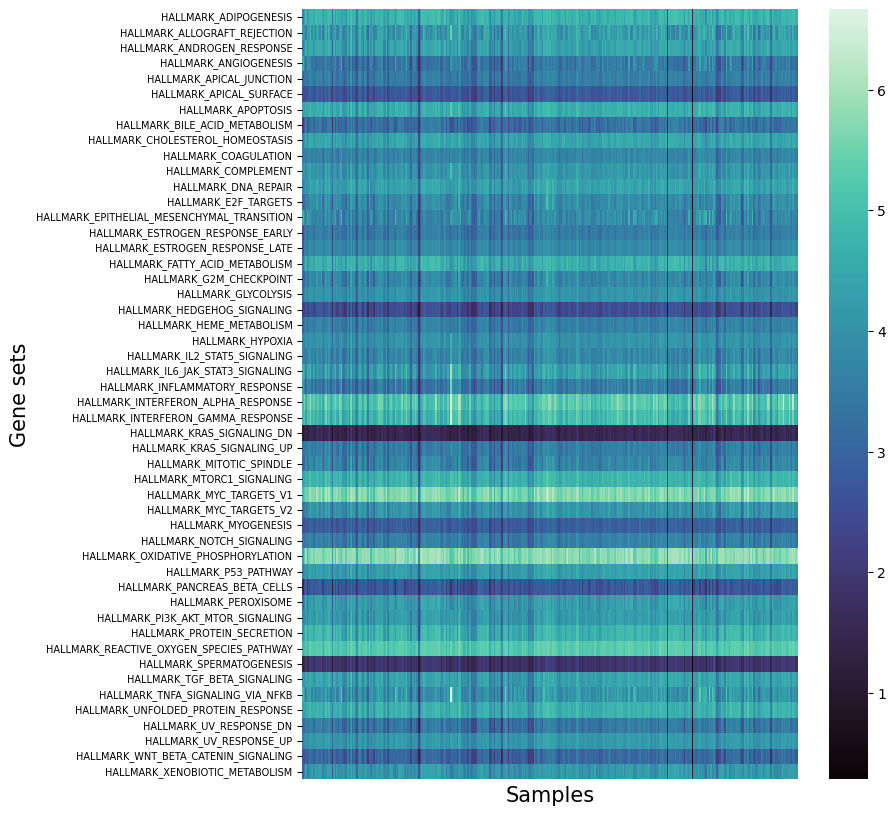

In [149]:
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(gene_set_expr_df.iloc[:, 1:], cmap="mako", ax=ax)
ax.set_yticklabels(gene_set_expr_df.index, fontsize=7)
ax.set_xlabel("Samples", fontsize=15)
ax.set_ylabel("Gene sets", fontsize=15)
ax.tick_params(axis="x", rotation=90)
ax.set_xticks([])
ax.set_xticklabels([]);

Those genes that were present in both the hallmark gene sets and the GEO expression dataset were singled out. Let us first construct a dataframe containing these relevant genes

In [150]:
relevant_genes_df = pd.DataFrame(index=gene_set_expr_df.index, columns=["relevant_genes"])

for _, gene_set_df in gene_sets_expr_dict.items():
    gene_set_name = gene_set_df.attrs["gene_set_name"]
    relevant_genes_df.loc[gene_set_name, "relevant_genes"] = list(gene_set_df.index.values)

relevant_genes_df.head()

,relevant_genes
gene_set_name,
HALLMARK_ADIPOGENESIS,"[ACO2, ECH1, RETSAT, JAGN1, GADD45A, ACADM, SO..."
HALLMARK_ALLOGRAFT_REJECTION,"[IL18RAP, BCL10, HDAC9, TNF, CCL22, F2R, IL27R..."
HALLMARK_ANDROGEN_RESPONSE,"[DBI, ALDH1A3, AKAP12, ADRM1, KRT8, GPD1L, SPC..."
HALLMARK_ANGIOGENESIS,"[PTK2, KCNJ8, POSTN, PDGFA, PRG2, COL5A2, FGFR..."
HALLMARK_APICAL_JUNCTION,"[MSN, PTEN, TRO, CLDN15, GAMT, TMEM8B, ZYX, PI..."


Now, we can add the `relevant_genes_df` values as a new column in the `gene_set_expr_df`

In [151]:
gene_set_expr_df = pd.concat([gene_set_expr_df, relevant_genes_df], axis=1)
gene_set_expr_df.head()

,GSM1598408,GSM1598409,GSM1598410,GSM1598411,GSM1598412,GSM1598413,GSM1598414,GSM1598415,GSM1598416,GSM1598417,...,GSM1598721,GSM1598722,GSM1598723,GSM1598724,GSM1598725,GSM1598726,GSM1598727,GSM1598728,GSM1598729,relevant_genes
gene_set_name,,,,,,,,,,,,,,,,,,,,,
HALLMARK_ADIPOGENESIS,4.673057,3.722162,4.276420,4.903253,3.979948,4.594571,4.655792,4.814399,4.477004,4.928155,...,4.824022,4.582675,4.766731,4.914146,4.799049,4.905908,5.022364,4.646561,4.765792,"[ACO2, ECH1, RETSAT, JAGN1, GADD45A, ACADM, SO..."
HALLMARK_ALLOGRAFT_REJECTION,3.722815,4.230910,4.181253,3.623362,4.442373,4.238733,4.968203,3.896786,4.386900,3.478985,...,4.622982,4.185091,4.232684,4.835743,3.944240,4.614053,3.982420,4.118930,3.494830,"[IL18RAP, BCL10, HDAC9, TNF, CCL22, F2R, IL27R..."
HALLMARK_ANDROGEN_RESPONSE,4.637928,3.634280,4.116811,4.644959,4.032413,4.509185,4.590260,4.483177,4.204952,4.578868,...,4.498439,4.492673,4.545977,4.716781,4.208033,4.490627,4.654086,4.345503,4.177016,"[DBI, ALDH1A3, AKAP12, ADRM1, KRT8, GPD1L, SPC..."
HALLMARK_ANGIOGENESIS,3.828766,4.541837,3.733954,3.262232,4.268141,3.820091,3.936092,3.311393,3.419089,3.185116,...,3.309054,3.815457,3.481230,3.994611,3.127381,3.313563,3.366346,3.172171,2.863064,"[PTK2, KCNJ8, POSTN, PDGFA, PRG2, COL5A2, FGFR..."
HALLMARK_APICAL_JUNCTION,3.520412,3.113608,3.334746,3.493098,3.291763,3.593859,3.882400,3.554246,3.391726,3.391995,...,3.733137,3.554528,3.662366,3.908353,3.379076,3.708916,3.676920,3.349899,3.206157,"[MSN, PTEN, TRO, CLDN15, GAMT, TMEM8B, ZYX, PI..."


We will need gene set expression data for further notebook. Let us save it

In [152]:
gene_set_expr_subdir = "gene_set_expressions"
gene_set_expr_filepath = f"{data_dir}/{gene_set_expr_subdir}/hallmark_expressions.parquet"

# Saving as a parquet file preserves the list structure of the relevant_genes column
gene_set_expr_df.to_parquet(f"{gene_set_expr_filepath}")